In [1]:
%run ../../../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset_builder import DatasetBuilder
from src.data.dataset import KidneyStoneDataset
from src.data.dataset_builder import DatasetBuilder, assign_task_labels
from src.pipelines.hybrid_resnet50_pipeline import HybridResNet50_pipeline
import pandas as pd
from src.features.feature_extractor import FeatureExtractor
from src.data.dataset import KidneyStoneDataset
from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor
from src.pipelines.xgboost_pipeline import XGBoostExperiment

In [ ]:
task_name = "multiclase"
task_config = TASKS[task_name]
builder = DatasetBuilder(DATASET_PATH)
xgboost_builder= DatasetBuilder(DATASET_PATH_XGBOOST)

df = builder.build(classes=task_config["classes"])
xgboost_df = xgboost_builder.build(classes=task_config["classes"])

lbp = LocalBinaryPattern()
hsv = HSV_extractor()
extractor = FeatureExtractor(hsv, lbp)
resnet50_model= HybridResNet50_pipeline(df= df, xgboost_df= xgboost_df, case=Case.IMAGE, extractor= extractor)

Use weighted cross entropy: True

EXPERIMENTO K-FOLD: hybrid_resnet50_multiclase
Total images: 397
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 278 images (215 cálculos)
  Val:   42 images (35 cálculos)
  Test:  77 images (62 cálculos)
Device: cuda
Trainable parameters: 536,581
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=1.4984 acc=0.4081 f1=0.4330 | val: loss=1.5143 acc=0.3810 f1=0.4131 | lr=1.00e-04 | 7.4s
Epoch   2/30 | train: loss=1.2688 acc=0.5257 f1=0.5296 | val: loss=1.3191 acc=0.5000 f1=0.5038 | lr=1.00e-04 | 7.6s
Epoch   3/30 | train: loss=1.1206 acc=0.5699 f1=0.5787 | val: loss=1.2657 acc=0.4762 f1=0.4704 | lr=1.00e-04 | 7.6s
Epoch   4/30 | train: loss=1.0851 acc=0.6434 f1=0.6519 | val: loss=1.2352 acc=0.5476 f1=0.5420 | lr=1.00e-04 | 7.1s
Epoch   5/30 | train: loss=0.9587 acc=0.6544 f1=0.6621 | val: loss=1.0985 acc=0.5952 f1=0.5899 | lr=1.00e-04 | 7.6s
Epoch   6/30 | train: loss=0.8818 acc=0.6912 f1=0.6919 | val: loss=

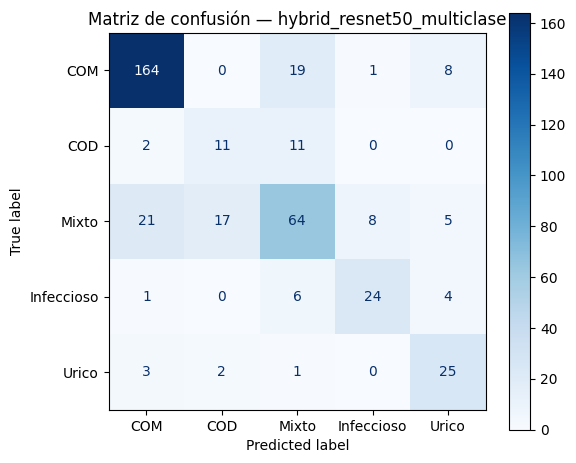


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.7236 ± 0.0494
  auc_weighted: 0.9052 ± 0.0195
  f1_weighted: 0.7211 ± 0.0536
  precision_weighted: 0.7557 ± 0.0383
  recall_weighted: 0.7236 ± 0.0494


{'name': 'hybrid_resnet50_multiclase',
 'fold_results': [{'accuracy': 0.6883116883116883,
   'precision_weighted': 0.7658355747416056,
   'recall_weighted': 0.6883116883116883,
   'f1_weighted': 0.7054941811435317,
   'auc_weighted': 0.8986231533213962,
   'per_class': {'precision': [0.9565217391304348,
     0.25,
     0.5483870967741935,
     0.8333333333333334,
     0.7777777777777778],
    'recall': [0.6666666666666666,
     0.6666666666666666,
     0.68,
     0.5555555555555556,
     1.0],
    'f1': [0.7857142857142857,
     0.36363636363636365,
     0.6071428571428571,
     0.6666666666666666,
     0.875],
    'class_names': ['COM', 'COD', 'Mixto', 'Infeccioso', 'Urico']},
   'confusion_matrix': [[22, 0, 10, 0, 1],
    [0, 2, 1, 0, 0],
    [1, 6, 17, 1, 0],
    [0, 0, 3, 5, 1],
    [0, 0, 0, 0, 7]],
   'classification_report': {'COM': {'precision': 0.9565217391304348,
     'recall': 0.6666666666666666,
     'f1-score': 0.7857142857142857,
     'support': 33.0},
    'COD': {'precis

In [4]:

config = {
    "name": f"hybrid_resnet50_{task_name}",
    "output_dir": f"experiments/hybrid_resnet50/hybrid_resnet50_images/hybrid_resnet50_{task_name}",
    "class_names": task_config["class_names"],
    "batch_size": 8
}

resnet50_model.run_model(config, show_fold_metrics= True, use_weighted_cross_entropy= True)


